# Feature Engineering

## Table of Contents

----

## Requirements

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import emd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

## Timeframe Refining & Train-Test Split

In [3]:
data = pd.read_csv('../data/raw/dataset_2019_2025.csv')
data['datetime'] = pd.to_datetime(data['datetime'], utc=True)
data = data[data['datetime'].dt.year >= 2022]
data.to_csv('../data/raw/dataset_2022_2025.csv', index=False)
cols = [
    'datetime', 'price',
    'precipitation', 'cloud_cover', 'temperature', 'relative_humidity',
    'renewable_share_of_load', 'load',
    'sum_cbet'
]
df = data[cols]
print(df.shape)
df.head()

(26304, 9)


,datetime,price,precipitation,cloud_cover,temperature,relative_humidity,renewable_share_of_load,load,sum_cbet
26304,2022-01-01 00:00:00+00:00,41.33,0.025,87.50,11.425,85.50,86.5,41177.8,-8.397
26305,2022-01-01 01:00:00+00:00,43.22,0.025,100.00,11.225,86.25,86.3,39669.8,-6.700
26306,2022-01-01 02:00:00+00:00,45.46,0.100,100.00,11.100,86.00,83.4,39448.7,-5.457
26307,2022-01-01 03:00:00+00:00,37.67,0.000,96.75,10.850,86.50,80.0,39112.1,-4.827
26308,2022-01-01 04:00:00+00:00,39.70,0.000,100.00,10.775,86.00,78.7,38358.2,-4.569


## Empirical Mode Decomposition (EMD)

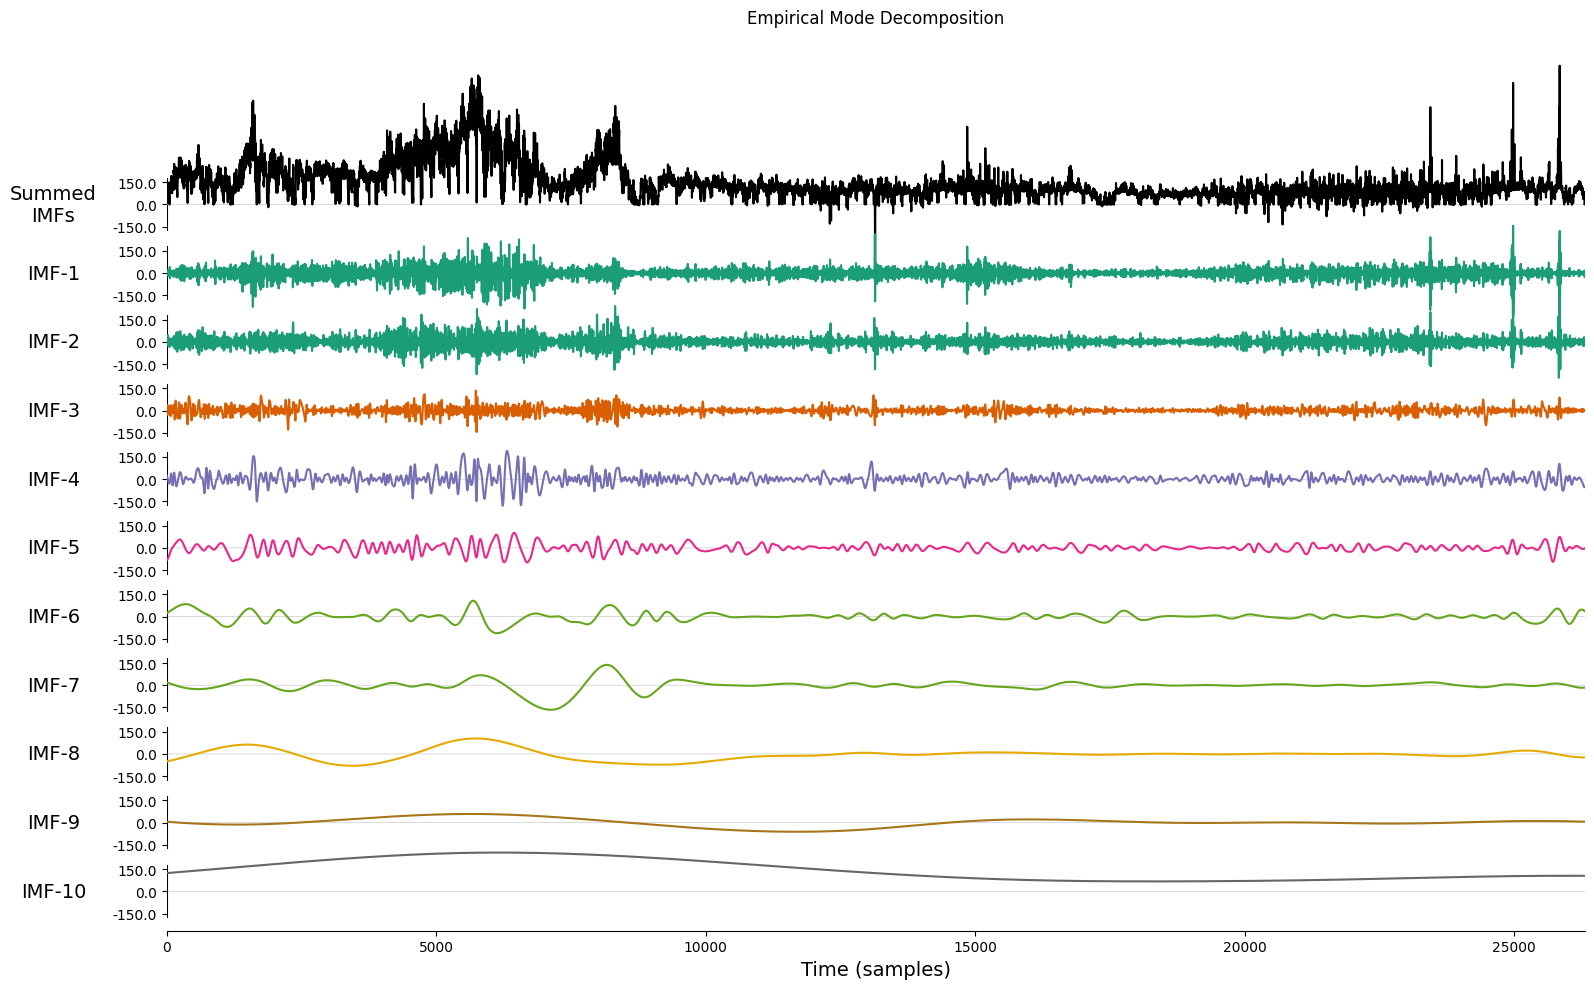

In [3]:
## These are the "regular" IMFs generated by EMD
### No clear mode mixing present
### (only insubstantial evidence of mode mixing for IMF-1/2/3)

price = df['price'].to_numpy()
imfs = emd.sift.sift(price)
emd.plotting.plot_imfs(imfs)
plt.title('Empirical Mode Decomposition')
plt.tight_layout()
plt.show()

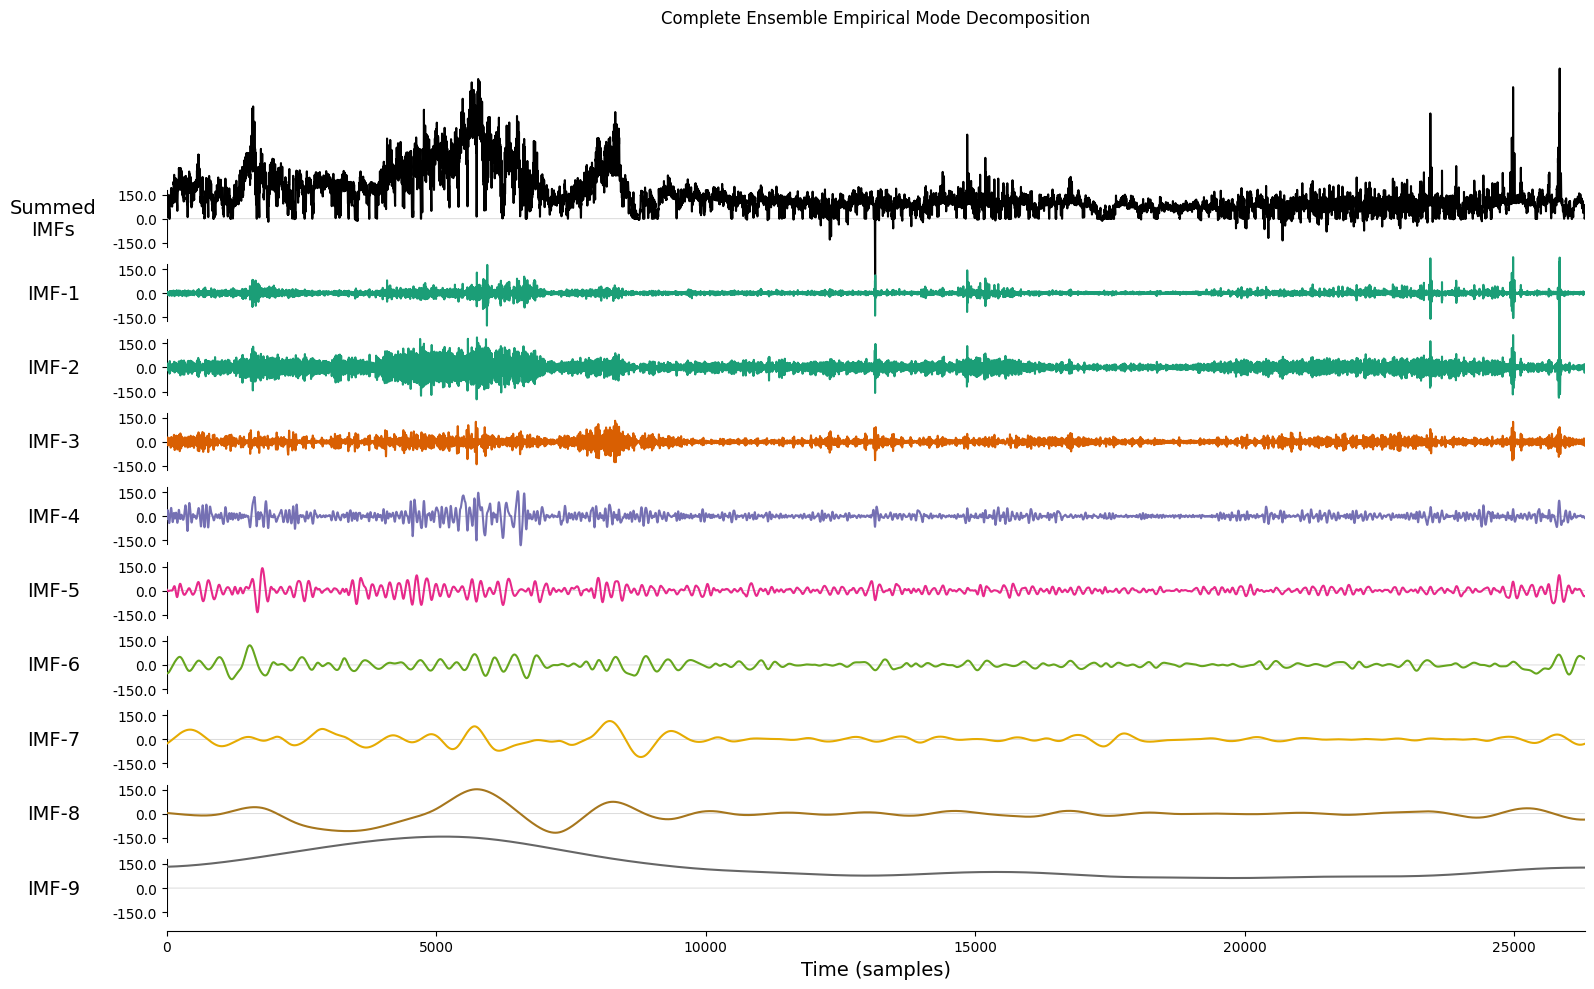

In [4]:
## Complete Ensemble IMFs
### Slight improvement in preventing mode mixing

ce_imfs = emd.sift.complete_ensemble_sift(price, max_imfs=7, nensembles=16, noise_seed=0)
emd.plotting.plot_imfs(ce_imfs)
plt.title('Complete Ensemble Empirical Mode Decomposition')
plt.tight_layout()
plt.show()

In [5]:
df_imf1 = df.copy(deep=True)
df_imf1['price_imf1'] = ce_imfs[:, 0]

df_imf2 = df.copy(deep=True)
df_imf2['price_imf2'] = ce_imfs[:, 1]

df_imf3 = df.copy(deep=True)
df_imf3['price_imf3'] = ce_imfs[:, 2]

df_imf4 = df.copy(deep=True)
df_imf4['price_imf4'] = ce_imfs[:, 3]

df_imf5 = df.copy(deep=True)
df_imf5['price_imf5'] = ce_imfs[:, 4]

df_imf6 = df.copy(deep=True)
df_imf6['price_imf6'] = ce_imfs[:, 5]

df_imf7 = df.copy(deep=True)
df_imf7['price_imf7'] = ce_imfs[:, 6]

df_imf8 = df.copy(deep=True)
df_imf8['price_imf8'] = ce_imfs[:, 7]

df_imf9 = df.copy(deep=True)
df_imf9['price_imf9'] = ce_imfs[:, 8]

datasets = [df_imf1, df_imf2, df_imf3, df_imf4, df_imf5, df_imf6, df_imf7, df_imf8, df_imf9]

## Lagged Feature Selection

### Lagged Target Variables Selection

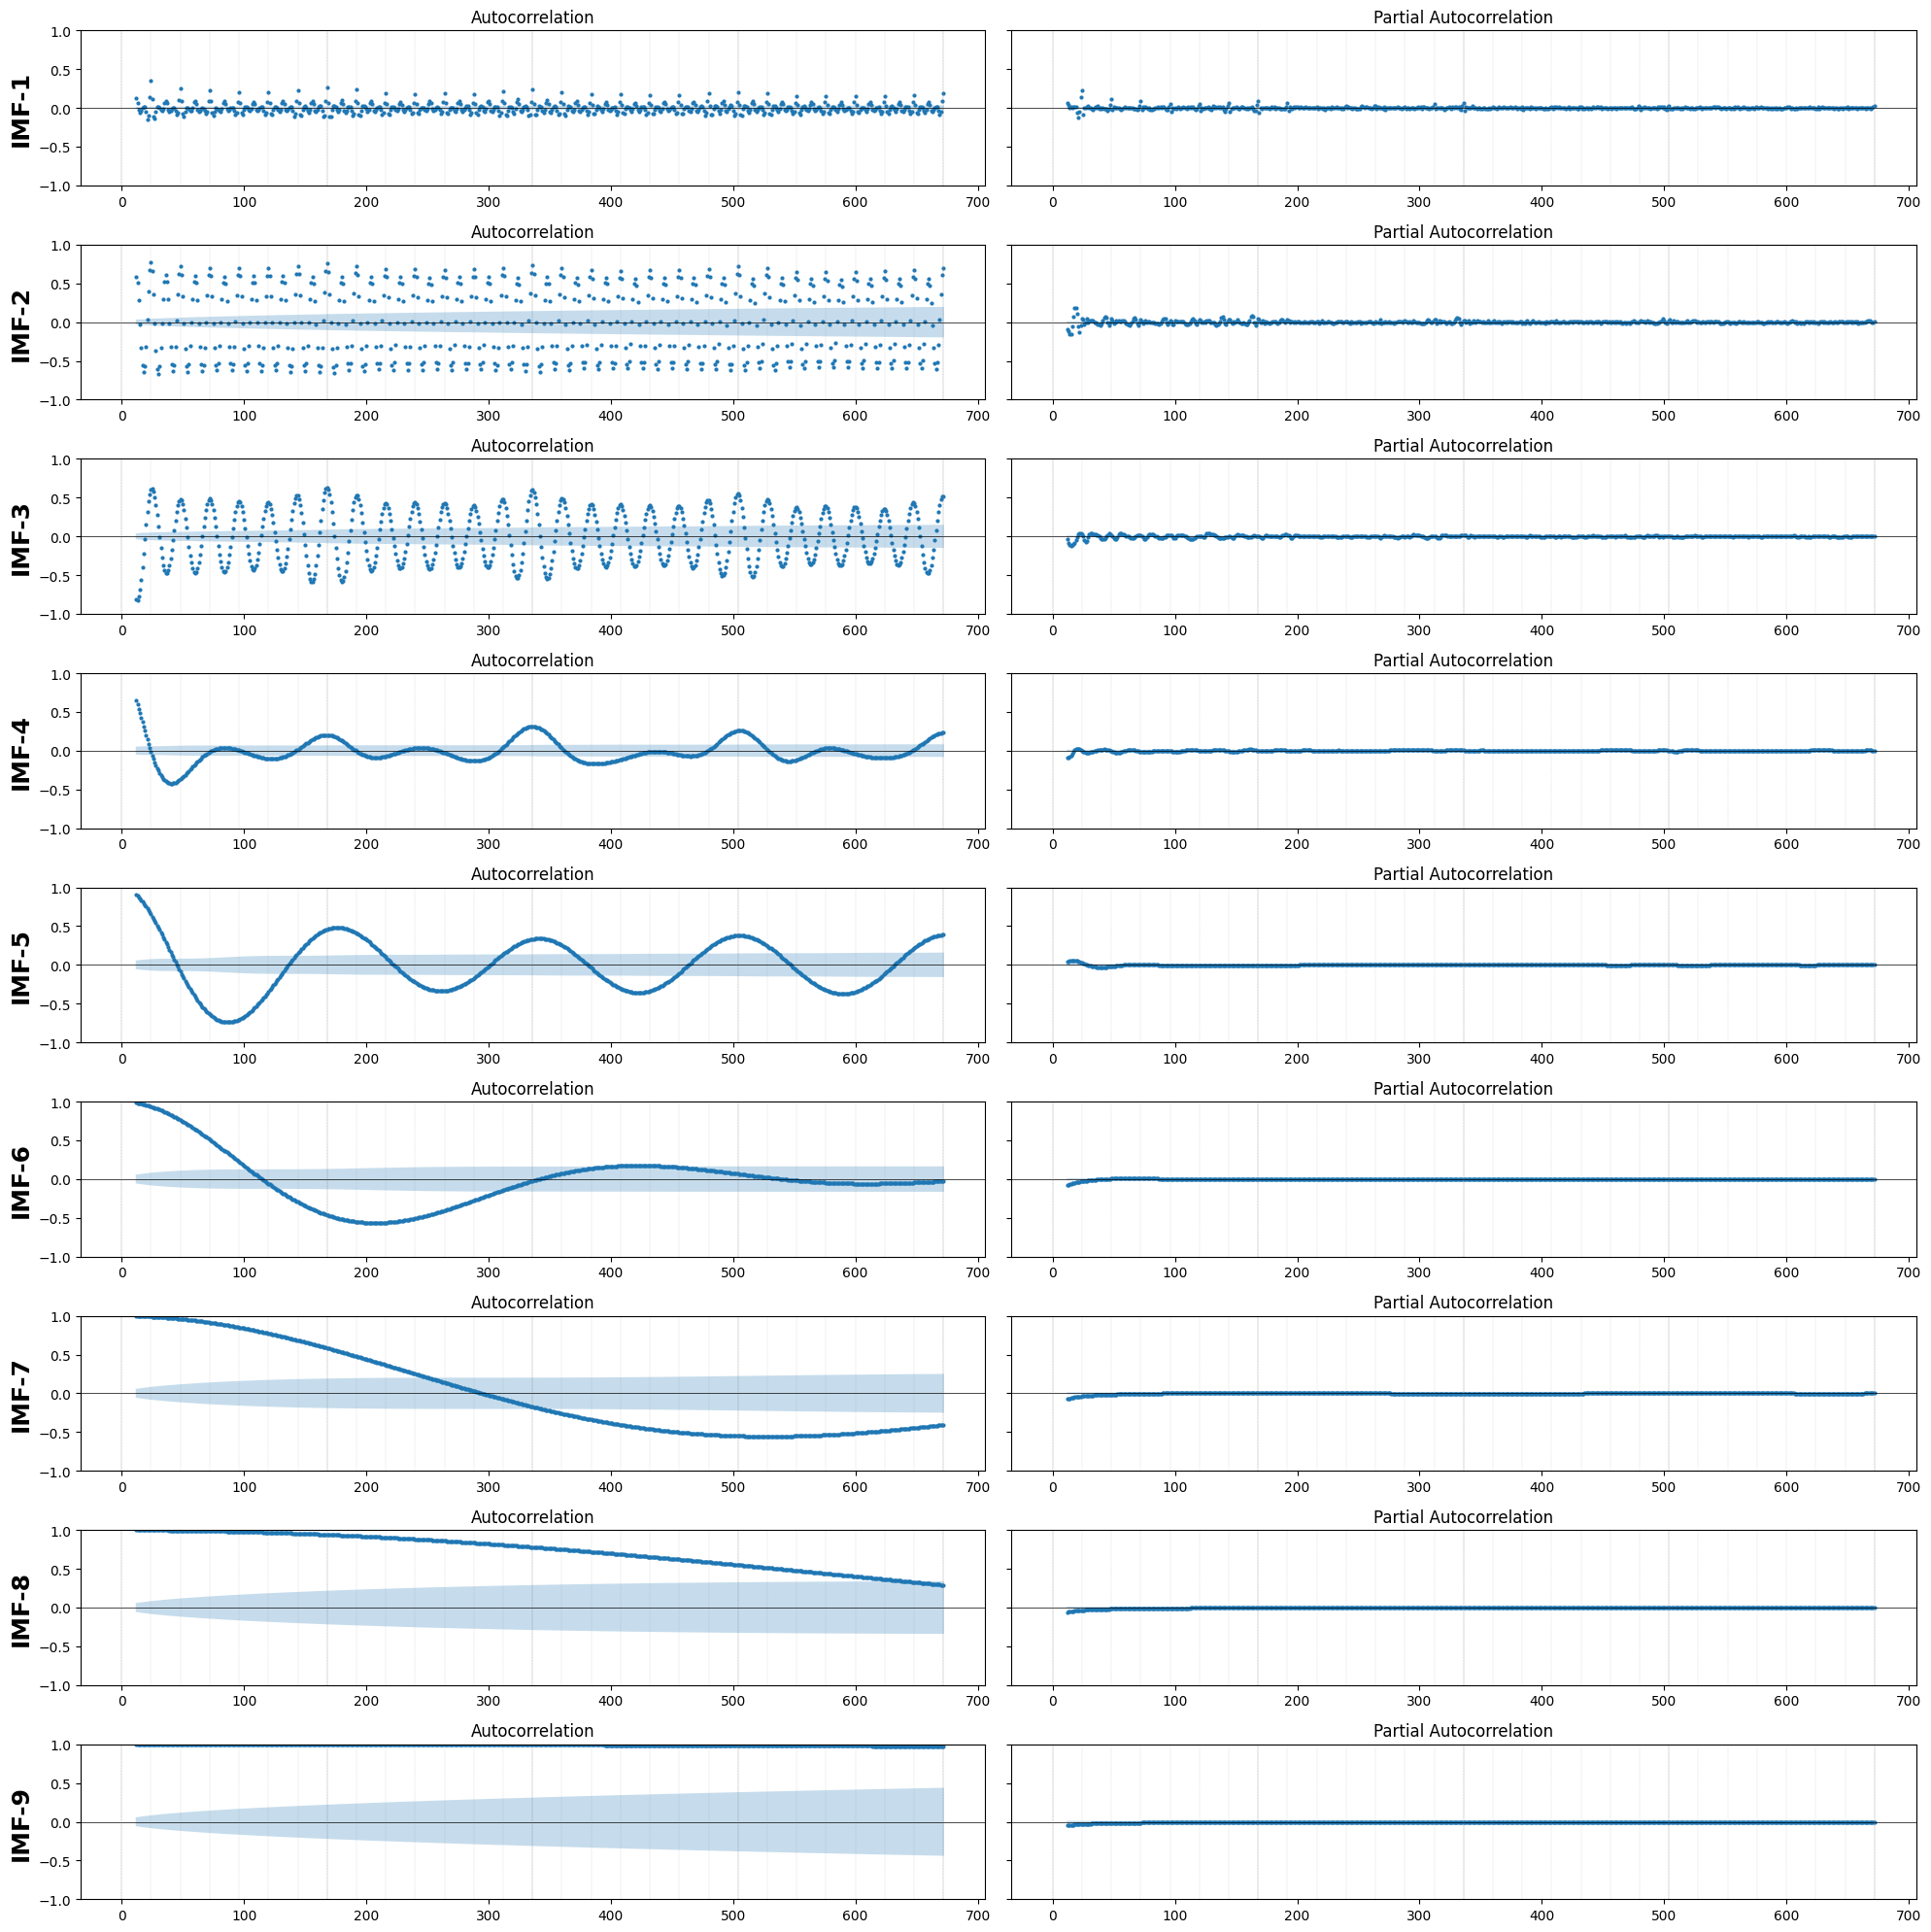

In [6]:
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(20, 20), sharey=True)

for row, dataset in enumerate(datasets):
    ax0, ax1 = axes[row][0], axes[row][1]

    plot_acf(x=dataset[f'price_imf{row+1}'], ax=ax0, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
    ax0.axhline(0, color='black', linewidth=0.5)
    ax0.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax0.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
    ax0.set_ylabel(f'IMF-{row+1}', fontweight='bold', fontsize=18)

    plot_pacf(x=dataset[f'price_imf{row+1}'], ax=ax1, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax1.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')

fig.tight_layout()
plt.show()

In [7]:
# lagged targets for IMF-1
for l in [_ for _ in range(12, 24+1)] + [_ for _ in range(24, 24*7+1, 24)] + [_ for _ in range(24*7, 24*7*4+1, 24*7)]:
    df_imf1.loc[:, f'price_imf1_l{l}'] = df_imf1.loc[:, 'price_imf1'].shift(l)

# lagged targets for IMF-2
for l in [_ for _ in range(12, 24+1)] + [_ for _ in range(24*7, 24*7*2+1, 24*7)]:
    df_imf2.loc[:, f'price_imf2_l{l}'] = df_imf2.loc[:, 'price_imf2'].shift(l)

# lagged targets for IMF-3
for l in [_ for _ in range(12, 24+1)] + [_ for _ in range(24, 24*7+1, 24)]:
    df_imf3.loc[:, f'price_imf3_l{l}'] = df_imf3.loc[:, 'price_imf3'].shift(l)

# lagged targets for IMF-4
for l in [_ for _ in range(int(24*7/4), int(24*7/4*2+1), int(24*7/4))]:
    df_imf4.loc[:, f'price_imf4_l{l}'] = df_imf4.loc[:, 'price_imf4'].shift(l)

# lagged targets for IMF-5
for l in [_ for _ in range(int(24*7/2), int(24*7/2*2+1), int(24*7/2))]:
    df_imf5.loc[:, f'price_imf5_l{l}'] = df_imf5.loc[:, 'price_imf5'].shift(l)

# lagged targets for IMF-6
for l in [_ for _ in range(24*7, 24*7*2+1, 24*7)]:
    df_imf6.loc[:, f'price_imf6_l{l}'] = df_imf6.loc[:, 'price_imf6'].shift(l)

# lagged targets for IMF-7
for l in [_ for _ in range(24*7*4, 24*7*4*2+1, 24*7*4)]:
    df_imf7.loc[:, f'price_imf7_l{l}'] = df_imf7.loc[:, 'price_imf7'].shift(l)

# lagged targets for IMF-8
for l in [_ for _ in range(24*7*8, 24*7*8*2+1, 24*7*8)]:
    df_imf8.loc[:, f'price_imf8_l{l}'] = df_imf8.loc[:, 'price_imf8'].shift(l)

*Use lags according to ACF & PACF interpretations + two lags for the implied frequency (i.e., long frequencies for late IMFs may be hard to appropriately illustrate).*

### Lagged Exogenous Variables Selection

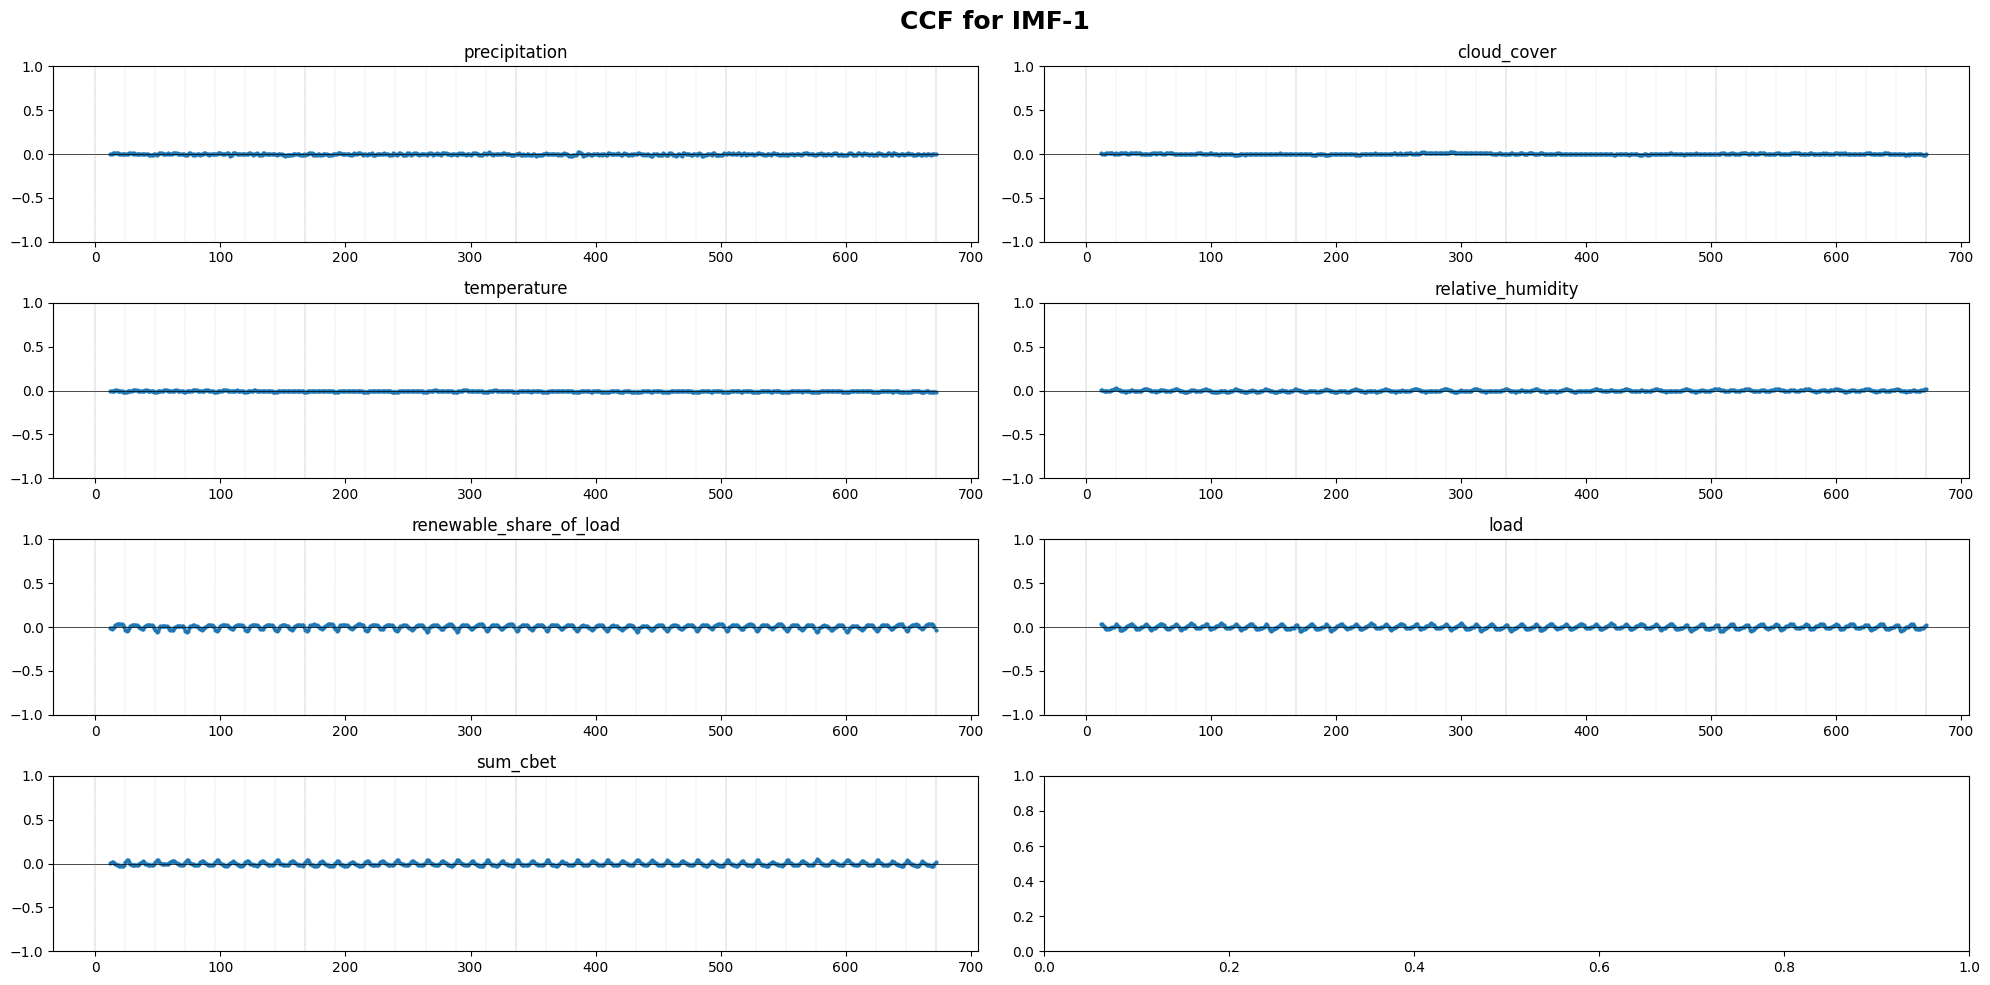

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


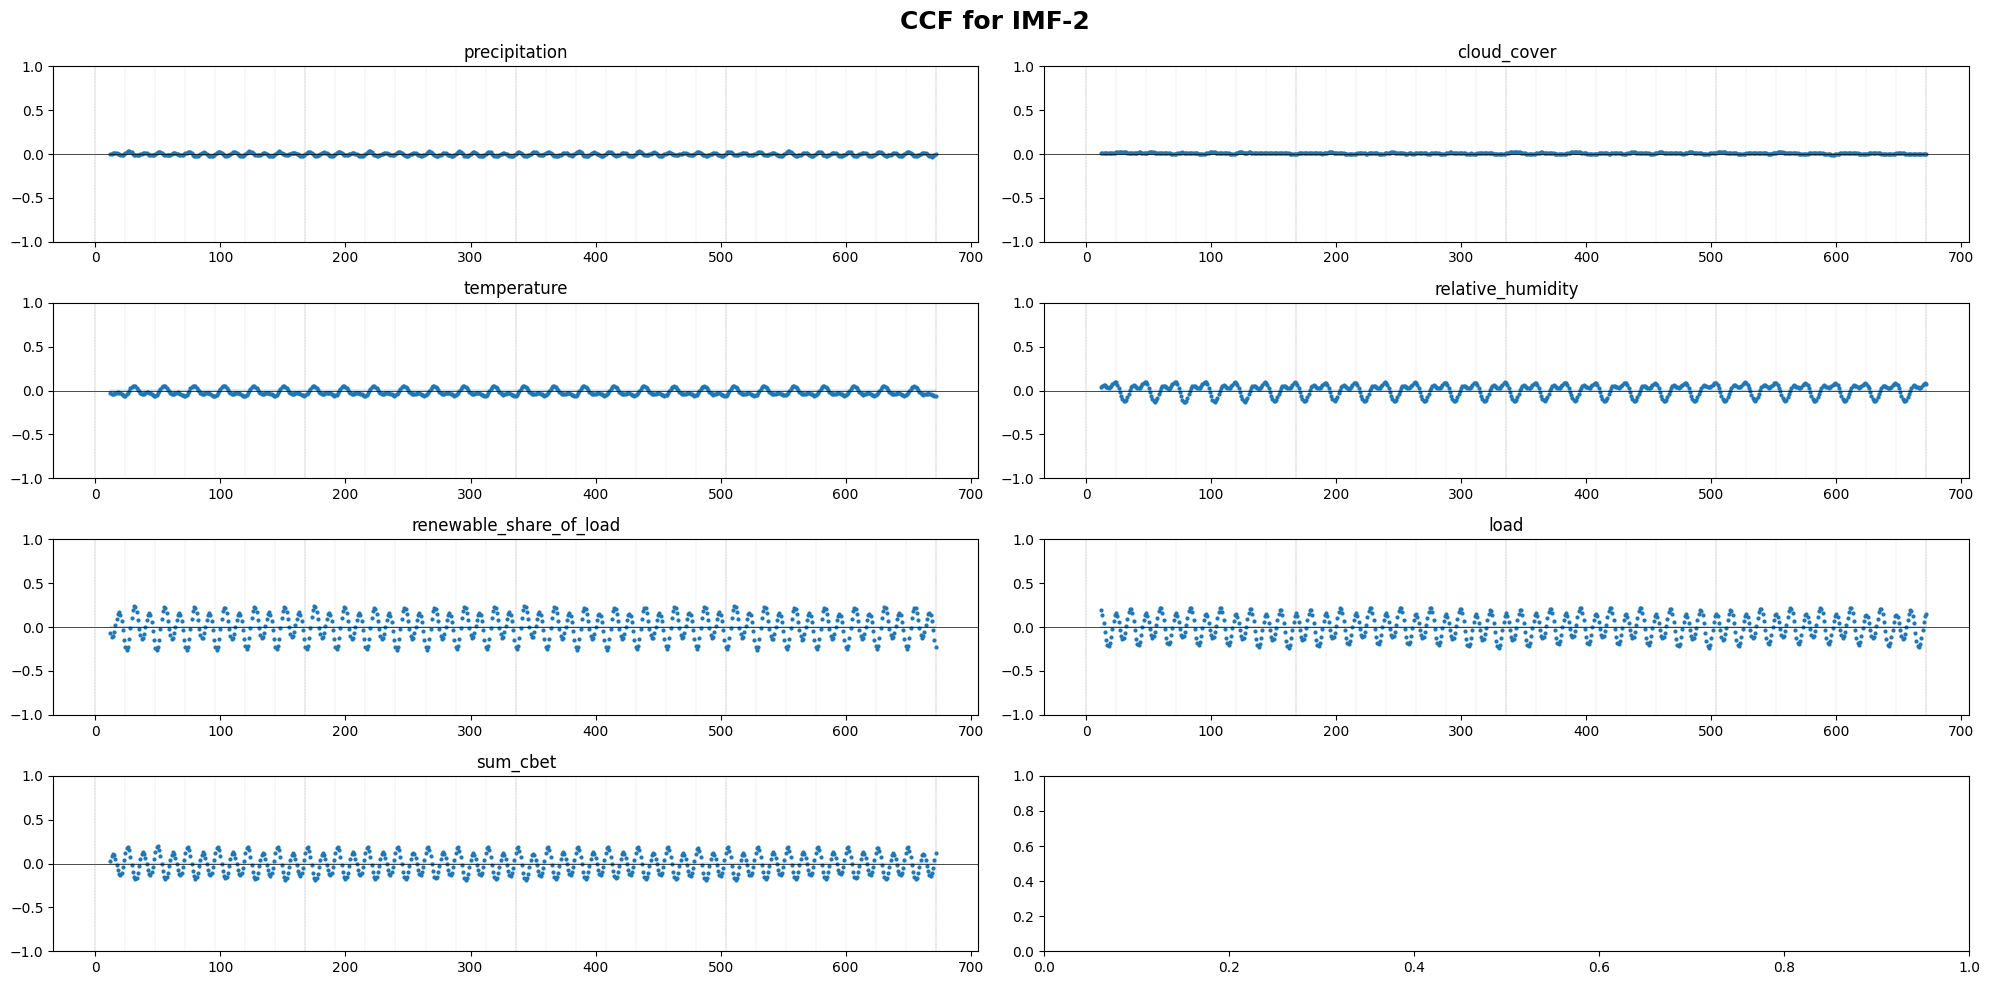

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


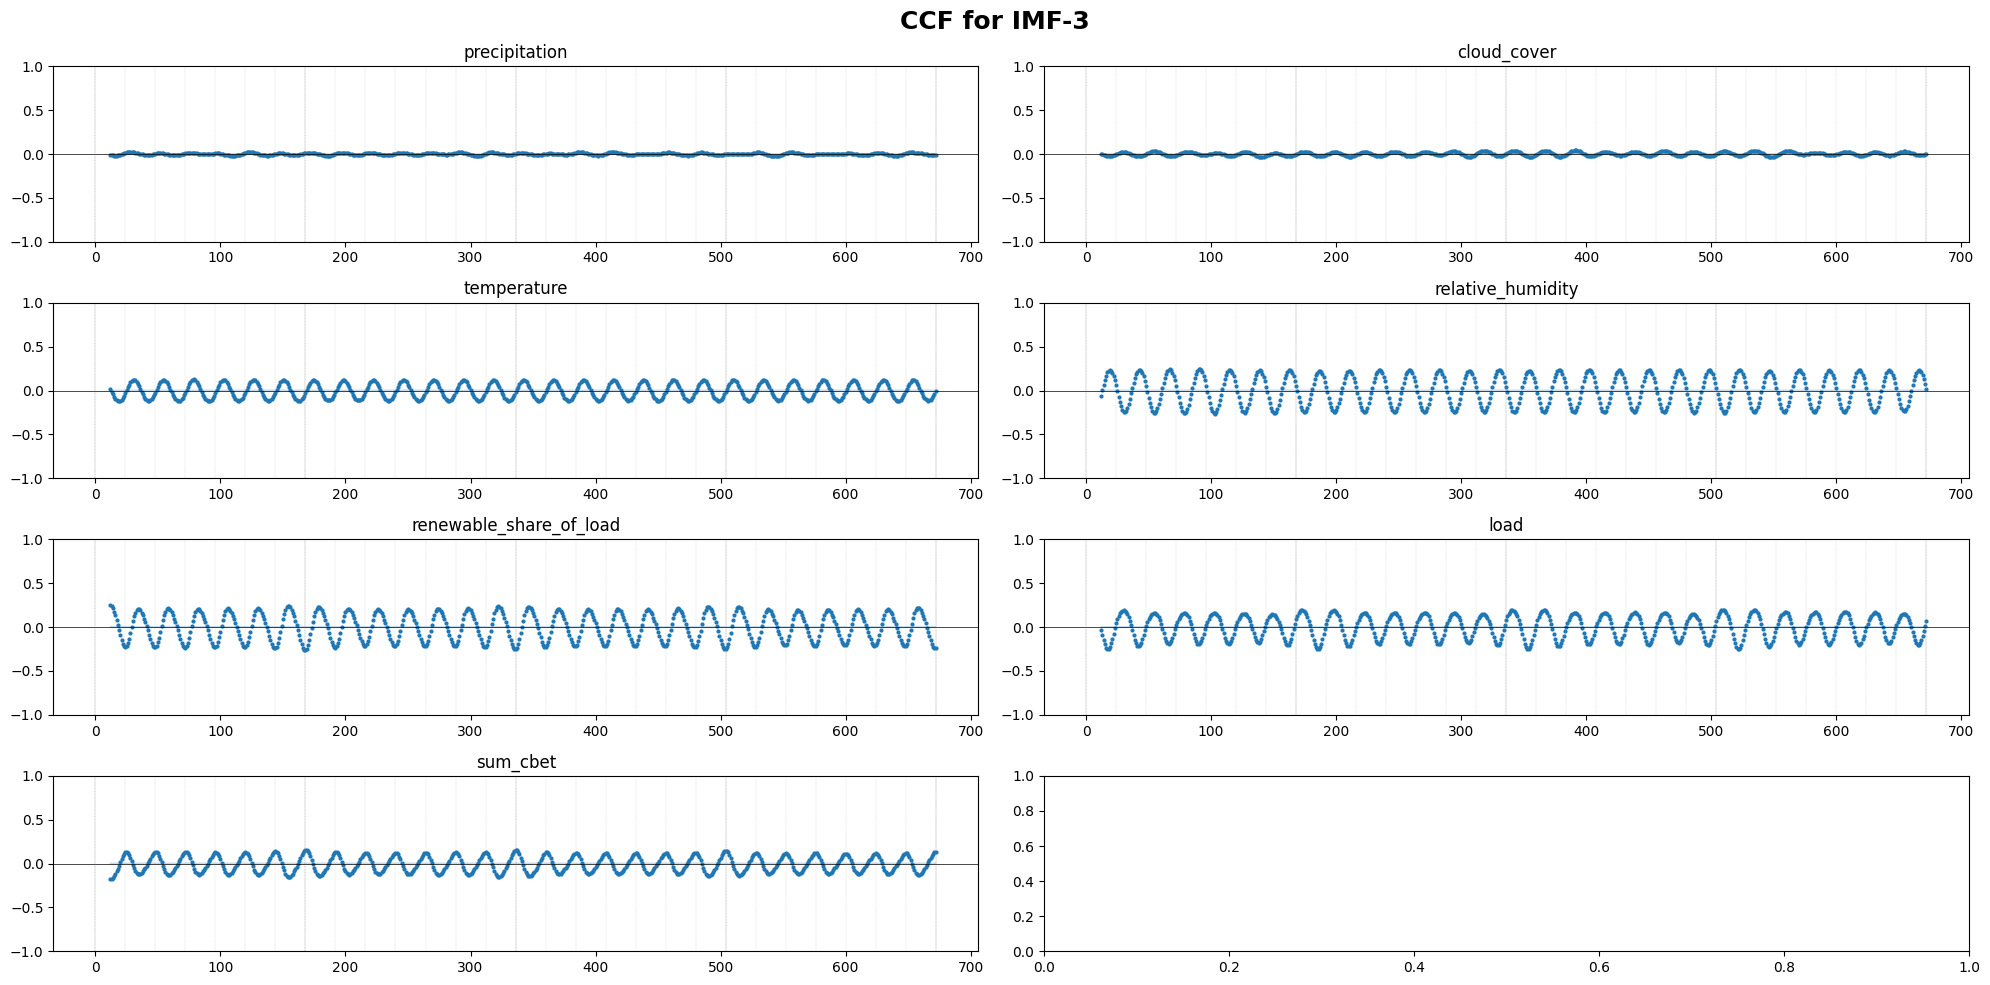

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


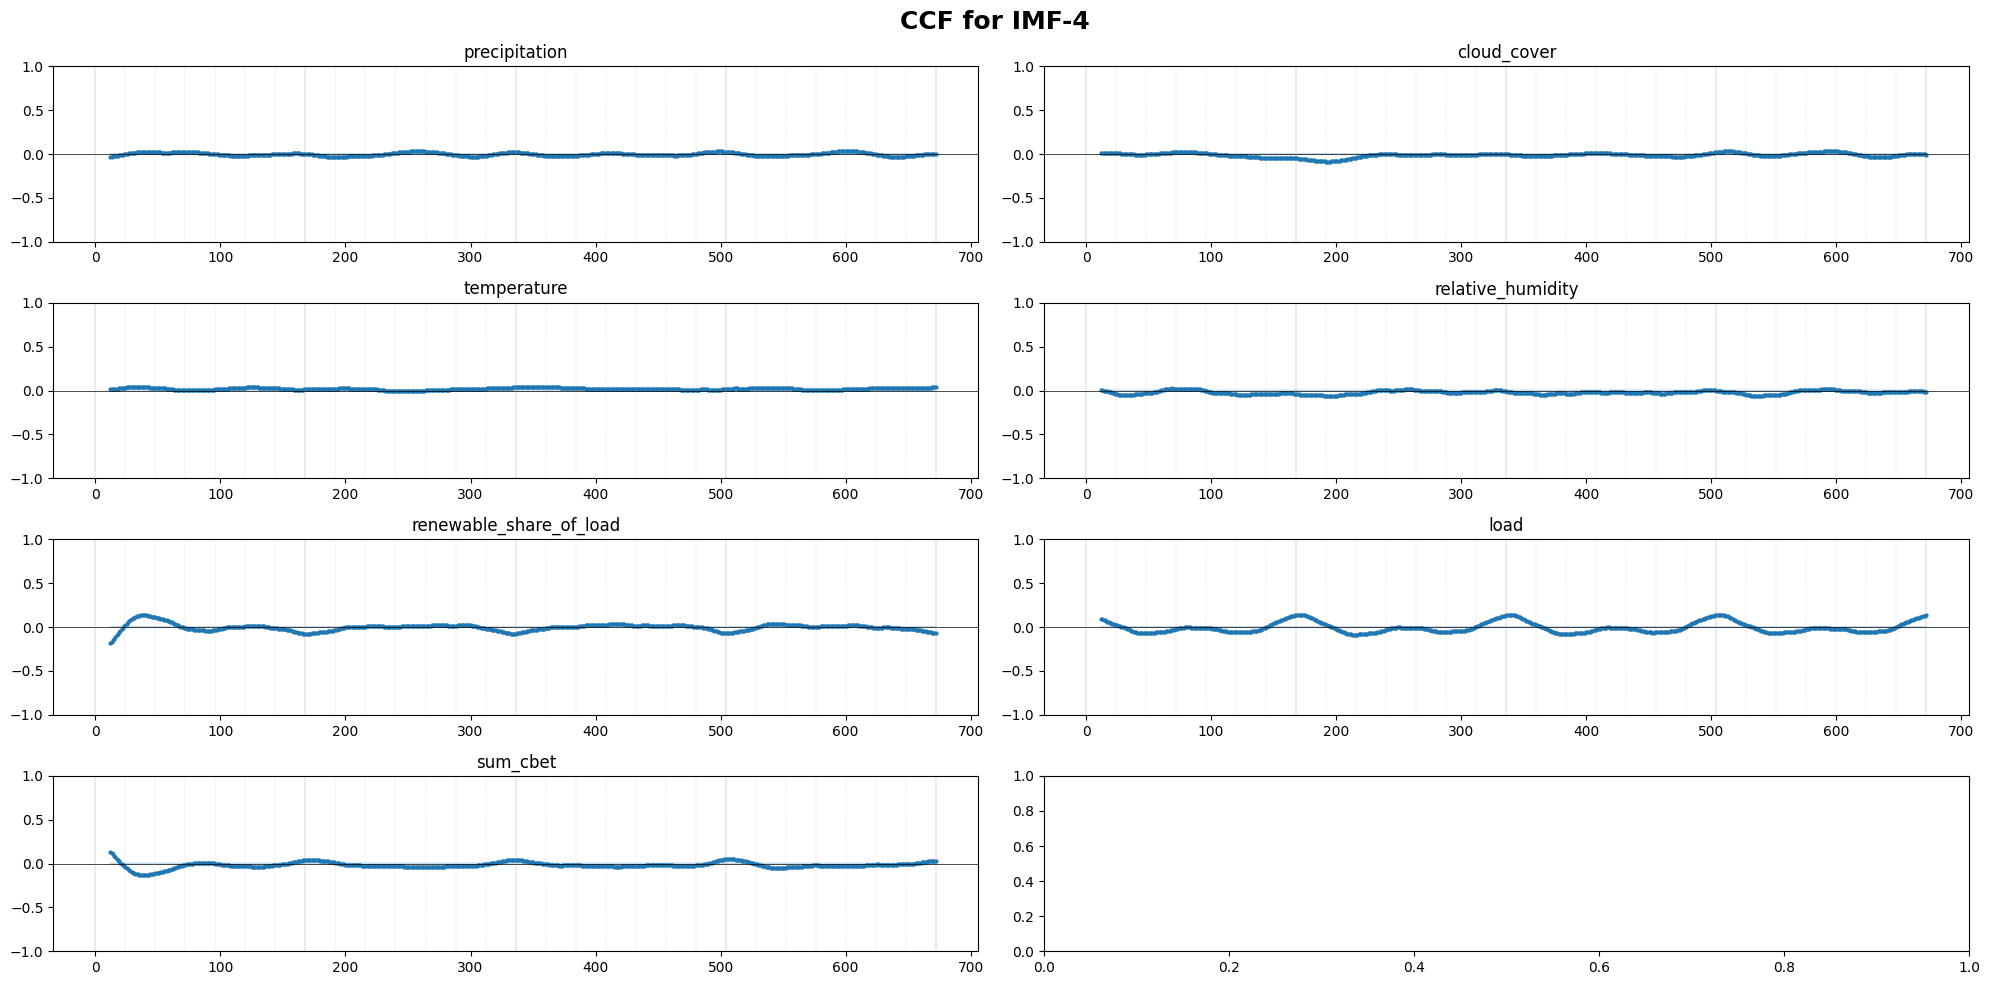

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


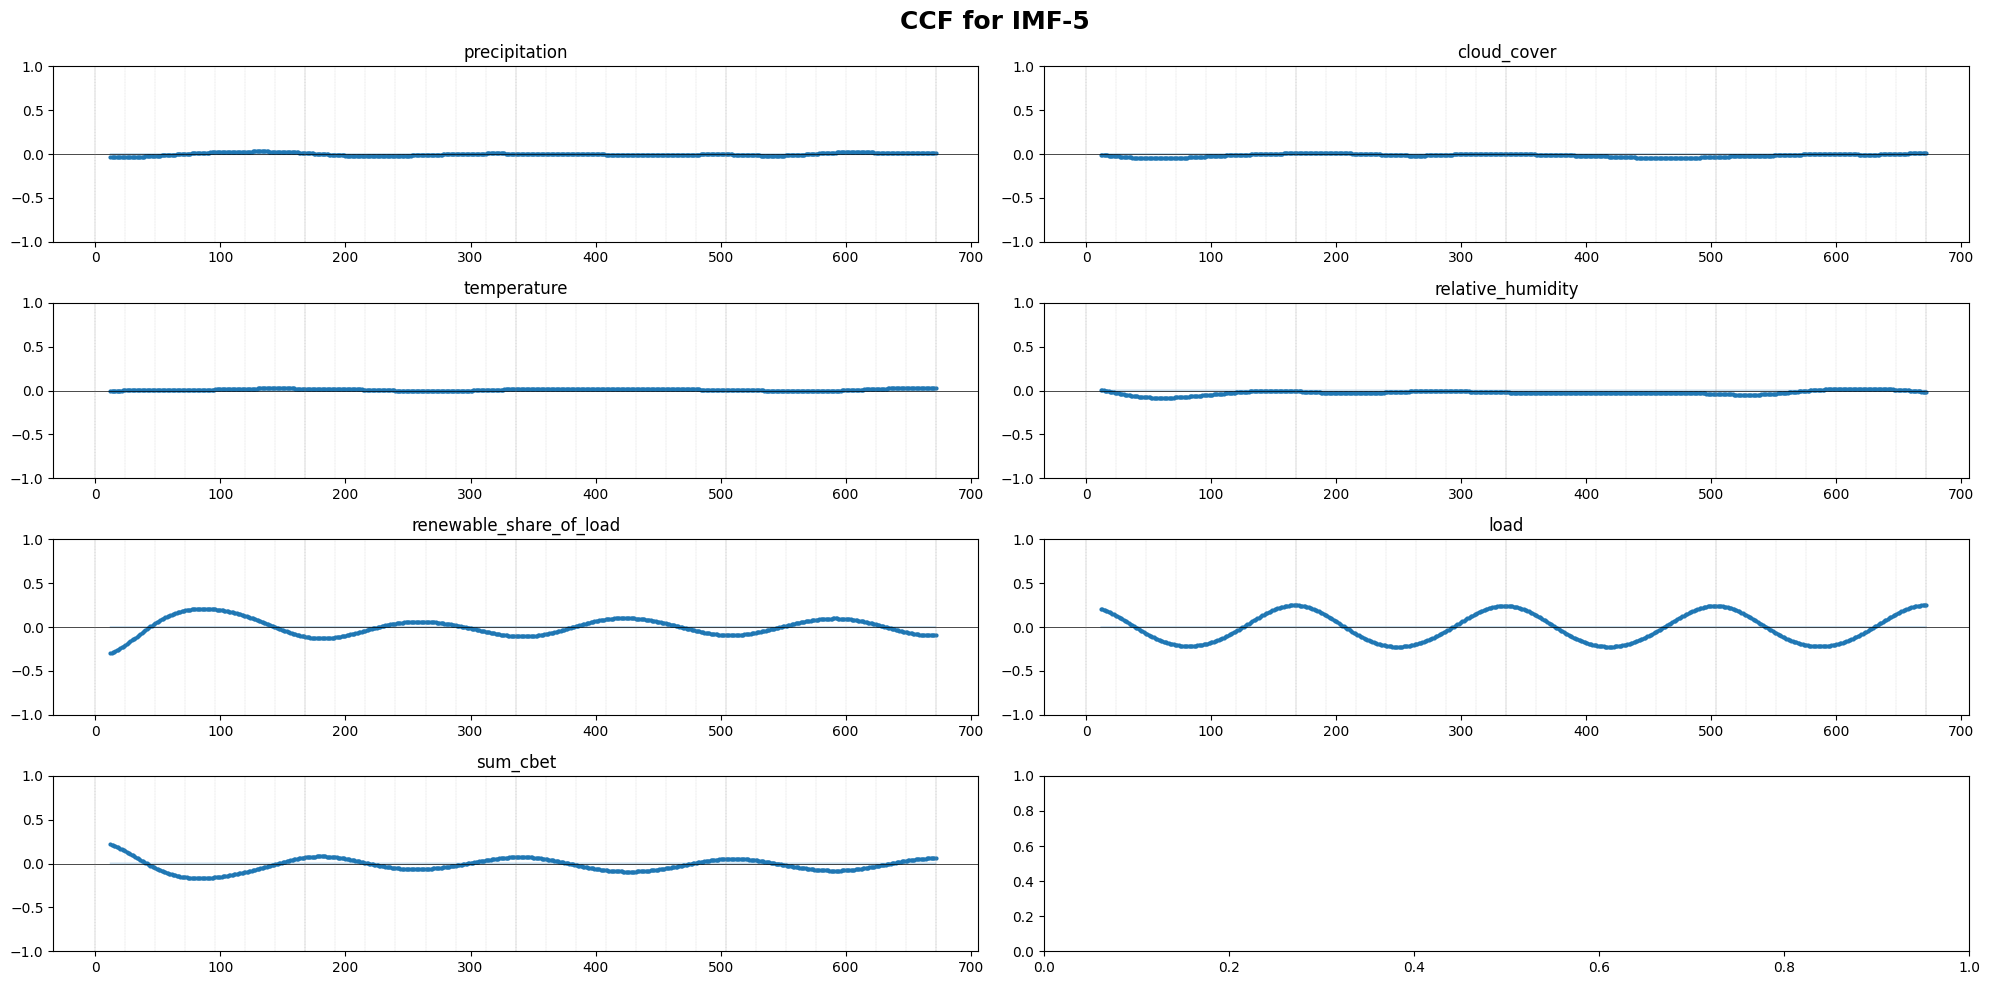

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


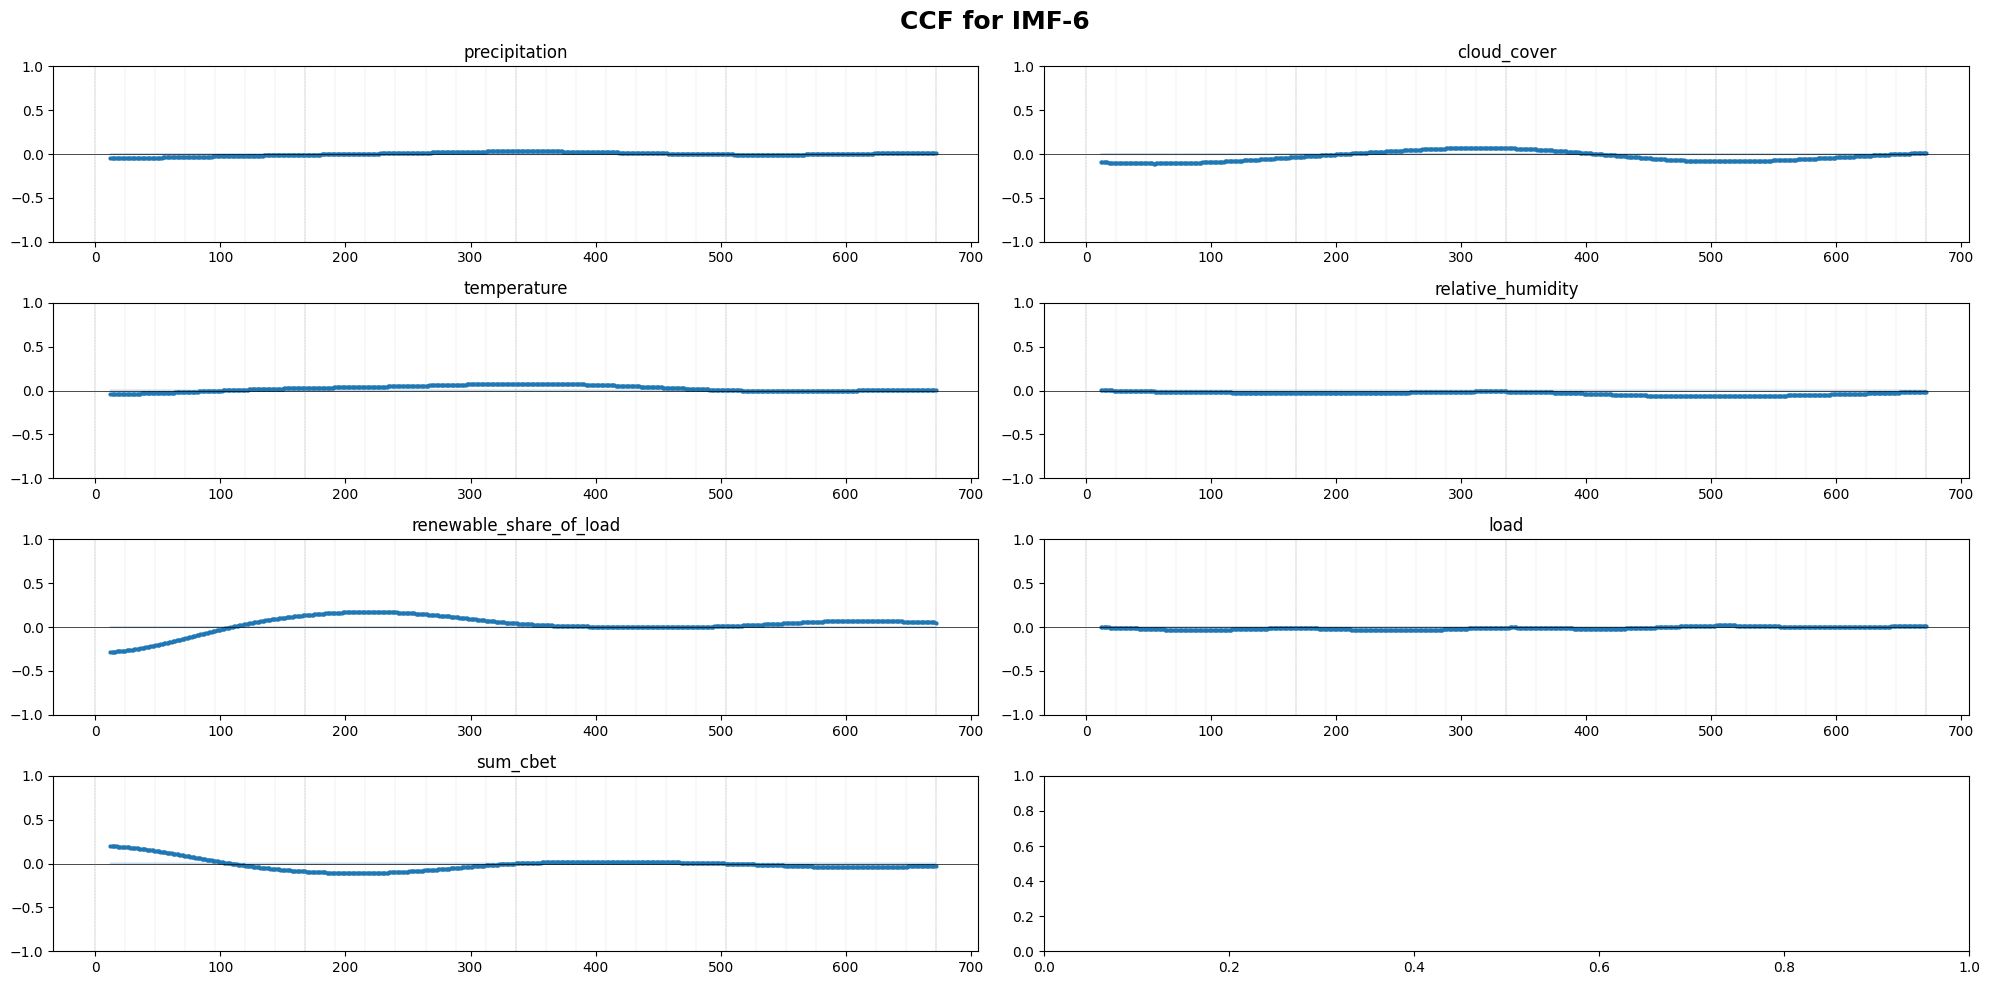

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


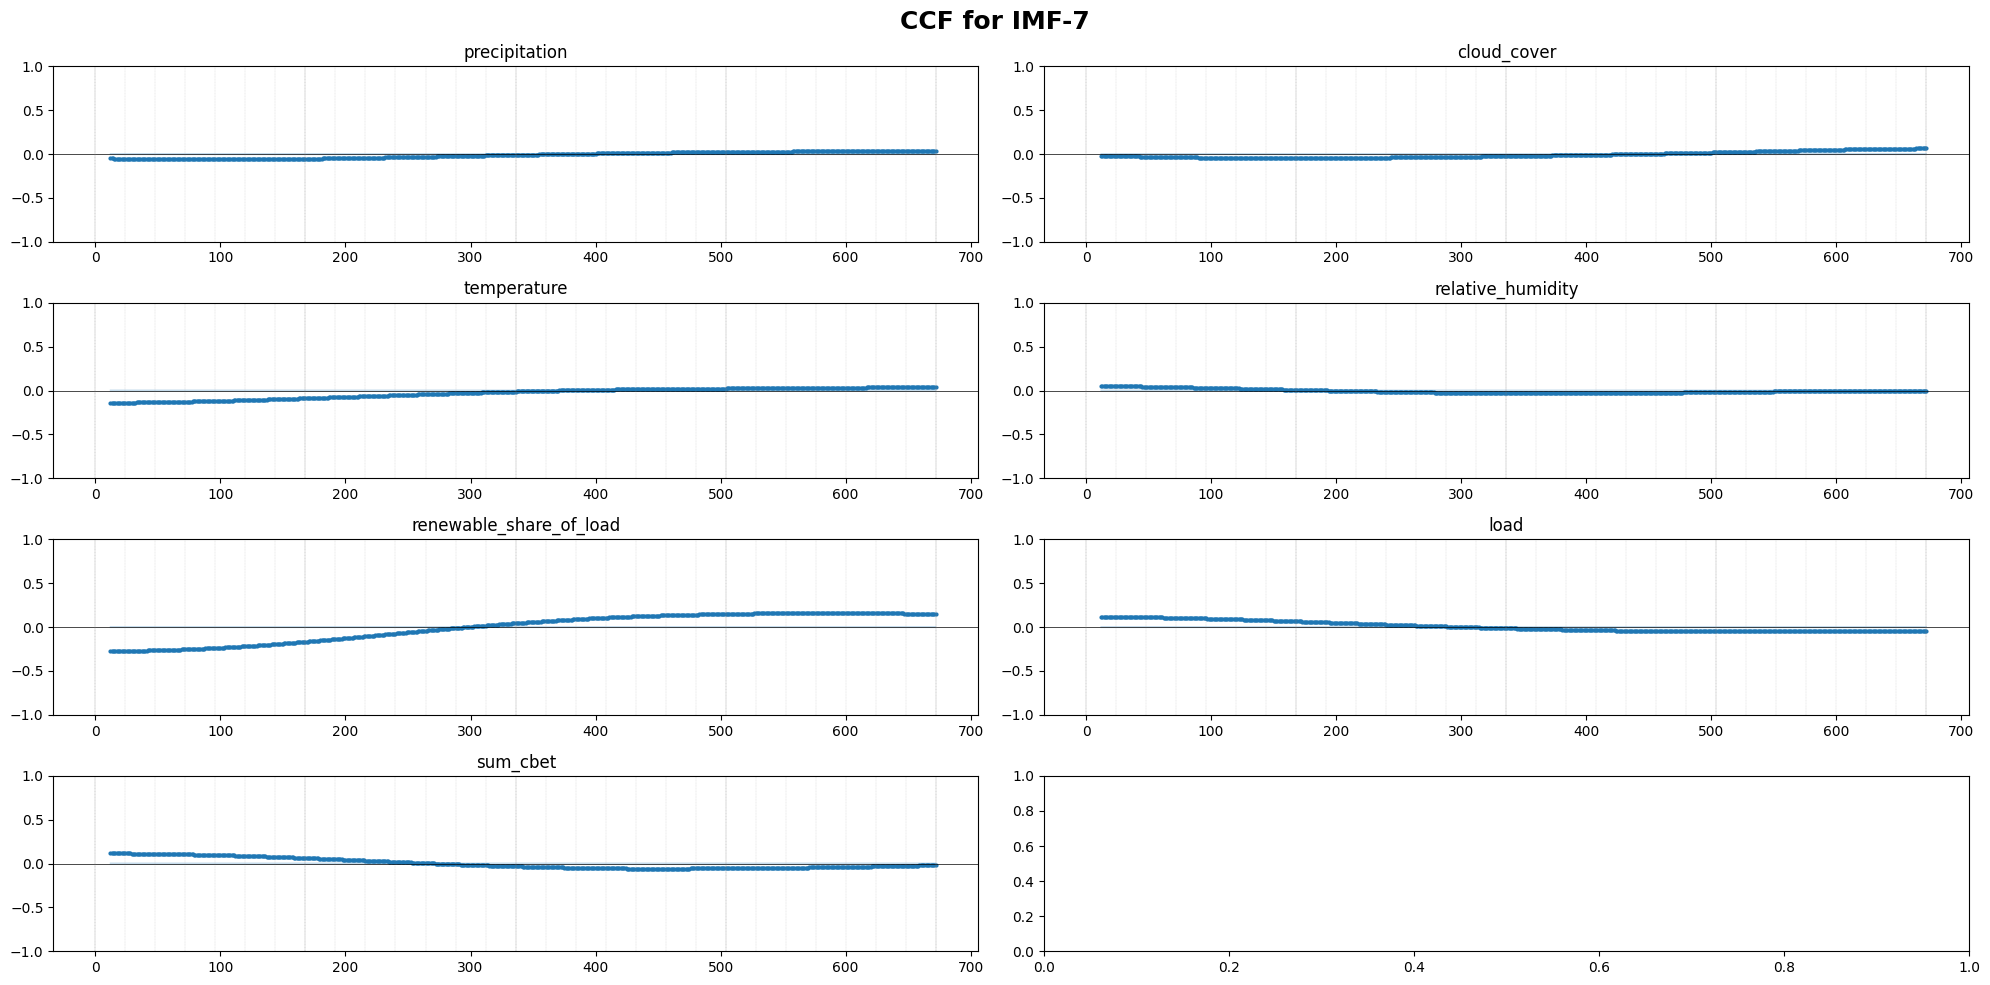

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


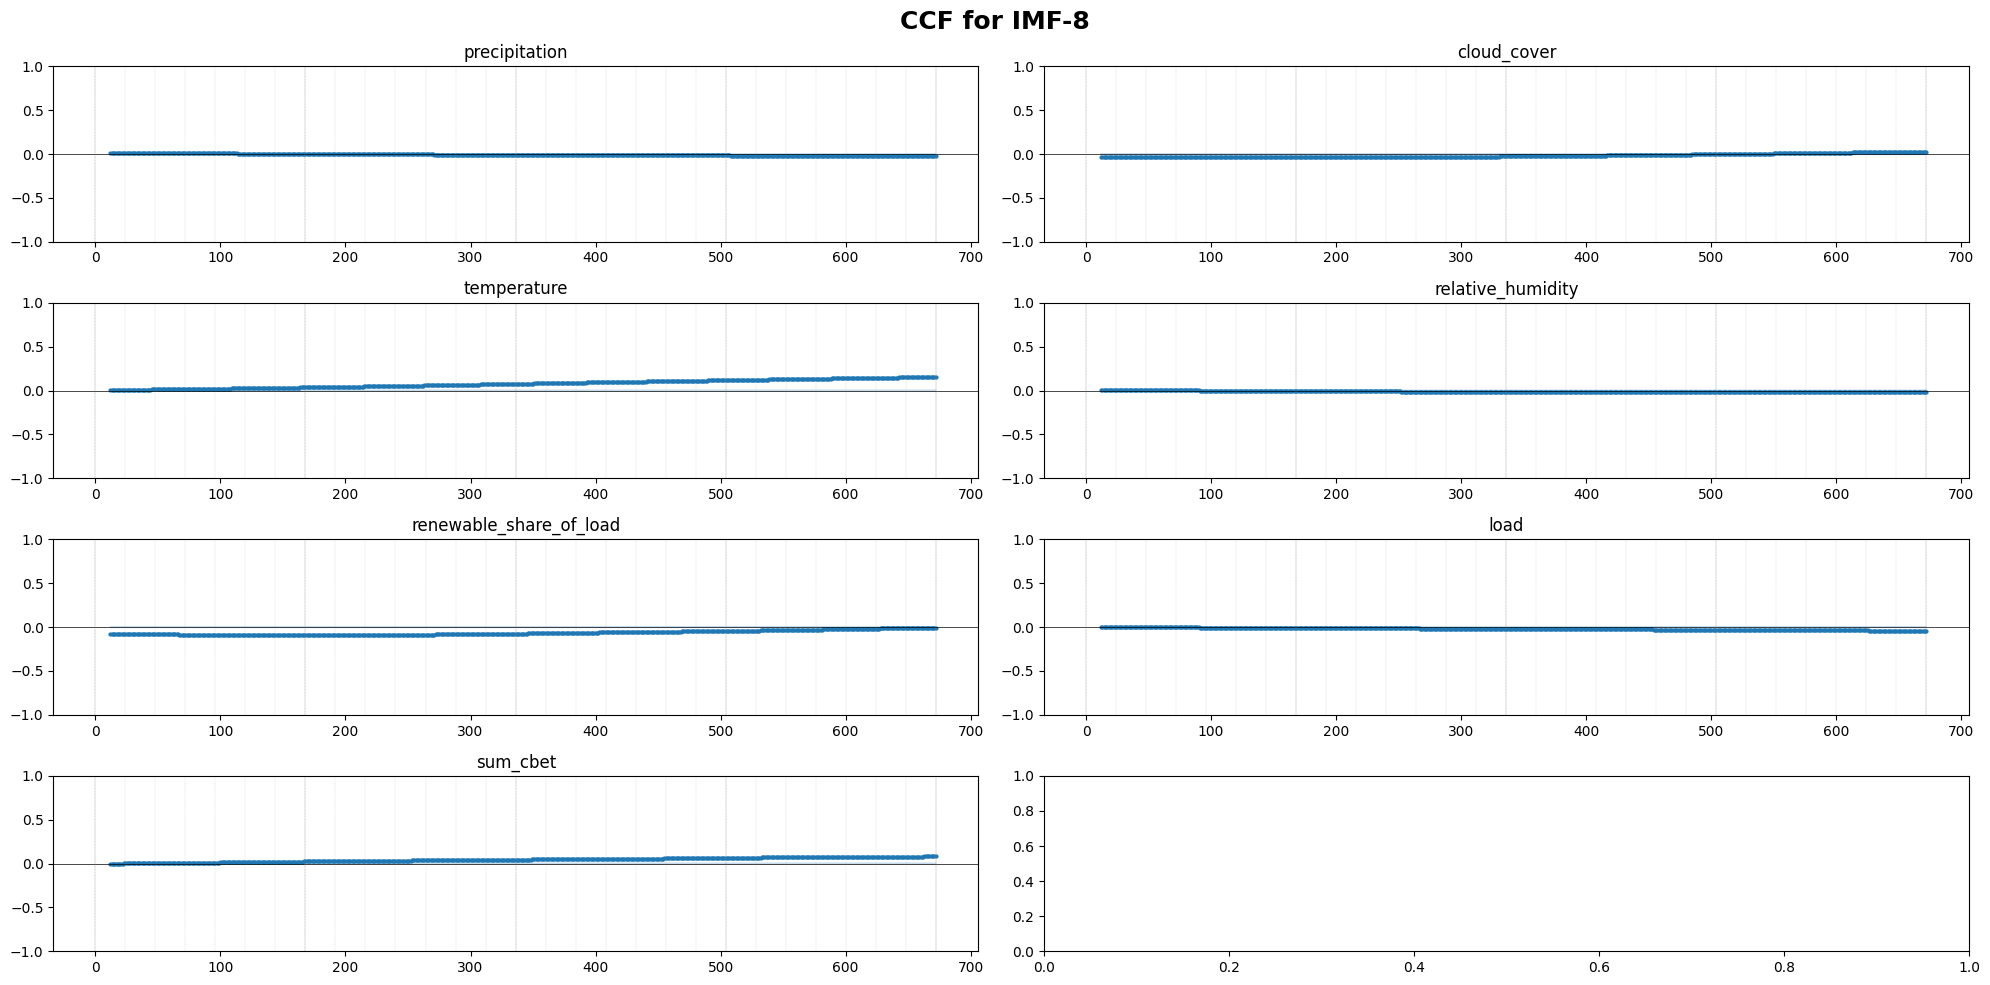

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


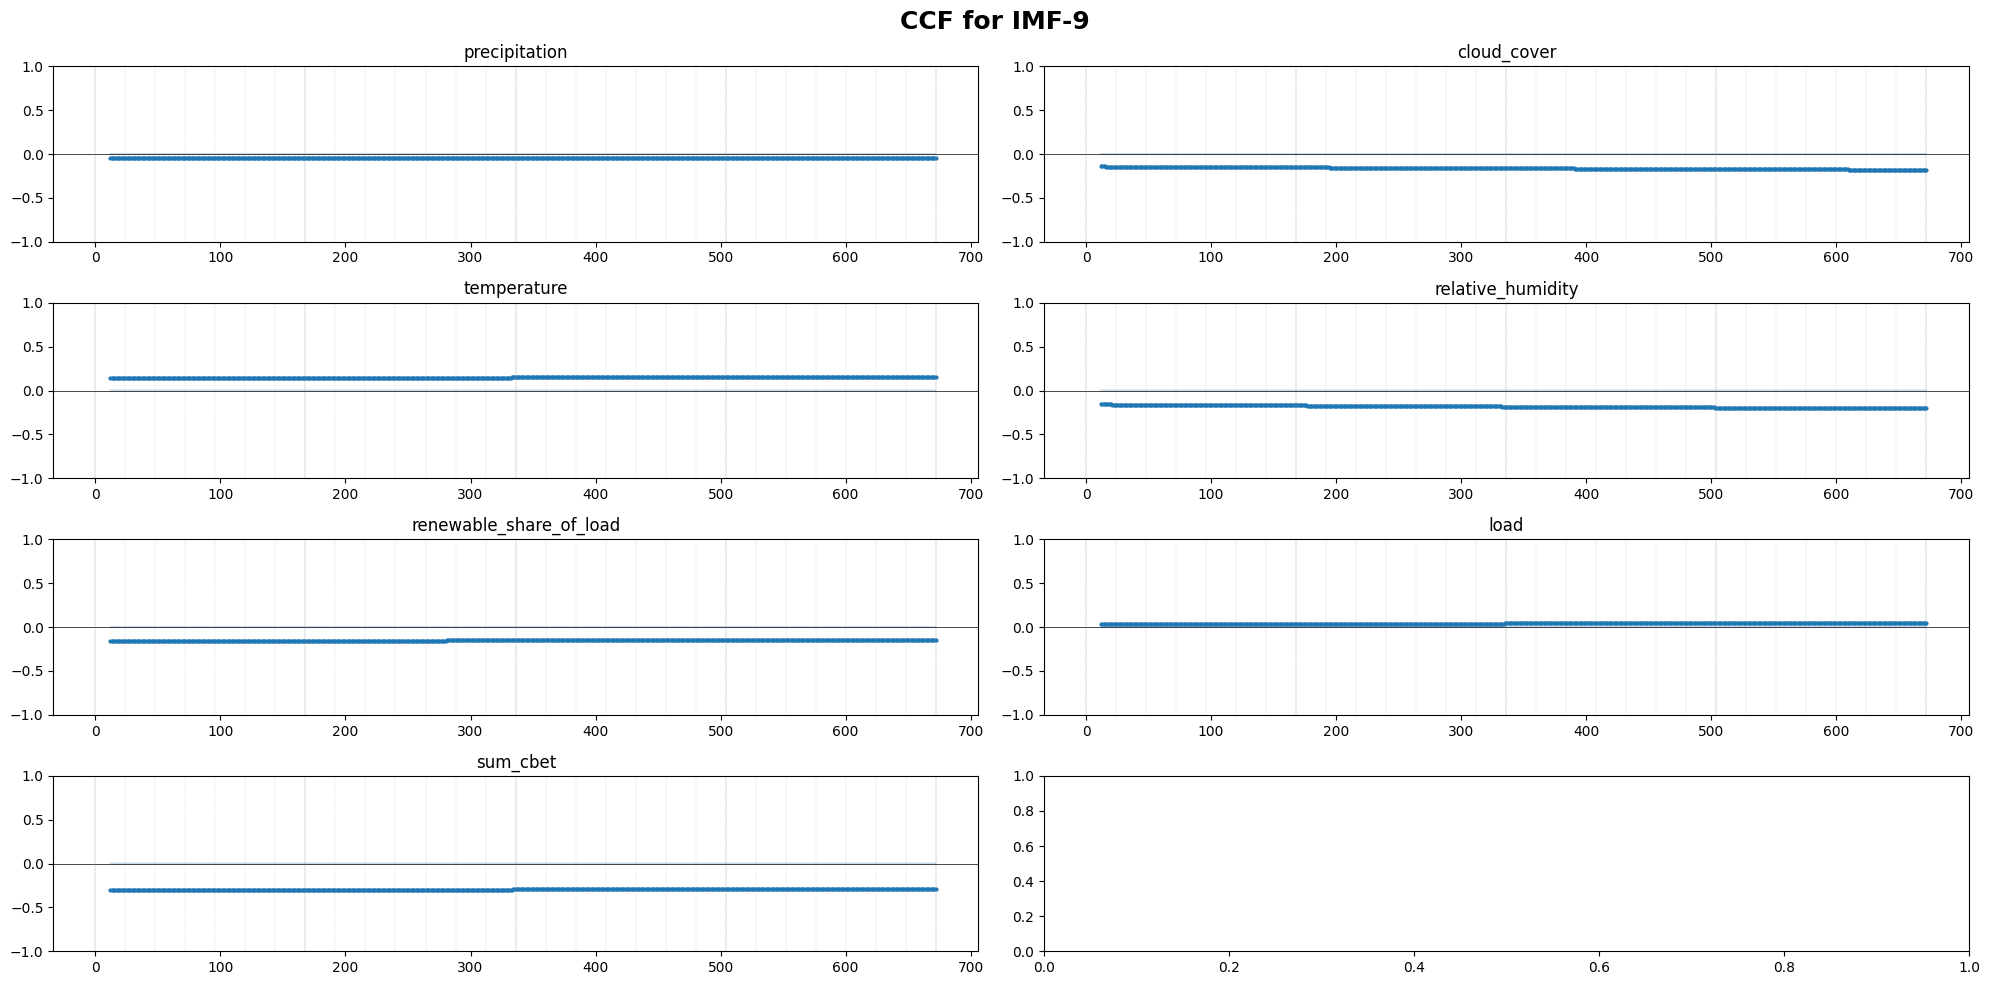

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [8]:
for i, dataset in enumerate(datasets):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 10))
    axes = axes.flatten()

    main_covar = [_ for _ in dataset.columns if 'datetime' not in _ and 'price' not in _]
    for j, col in enumerate(main_covar):
        ax = axes[j]
        plot_ccf(x=dataset[f'price_imf{i+1}'], y=dataset[col], alpha=0.05, ax=ax, lags=[_ for _ in range(12, 24*7*4+1)], use_vlines=False, markersize=2)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
        ax.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
        ax.set_title(col)

    fig.suptitle(f'CCF for IMF-{i+1}', fontweight='bold', fontsize=18)
    fig.tight_layout()
    plt.show()
    print('----'*64)

In [9]:
# lagged exogenous for IMF-2
tmp_data = df_imf2
for l in [_ for _ in range(24, 24*2+1, 24)]:
    tmp_data.loc[:, f'relative_humidity_l{l}'] = tmp_data.loc[:, 'relative_humidity'].shift(l)
for l in [_ for _ in range(24, 24*2+1, 24)]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 24)]:
    tmp_data.loc[:, f'load_l{l}'] = tmp_data.loc[:, 'load'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'sum_cbet_l{l}'] = tmp_data.loc[:, 'sum_cbet'].shift(l)

# lagged exogenous for IMF-3
tmp_data = df_imf3
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'temperature_l{l}'] = tmp_data.loc[:, 'temperature'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'relative_humidity_l{l}'] = tmp_data.loc[:, 'relative_humidity'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'load_l{l}'] = tmp_data.loc[:, 'load'].shift(l)
for l in [_ for _ in range(12, 24*2+1, 12)]:
    tmp_data.loc[:, f'sum_cbet_l{l}'] = tmp_data.loc[:, 'sum_cbet'].shift(l)

# lagged exogenous for IMF-4
tmp_data = df_imf4
for l in [36]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)
for l in [_ for _ in range(24*7, 24*7*2+1, 24*7)]:
    tmp_data.loc[:, f'load_l{l}'] = tmp_data.loc[:, 'load'].shift(l)
for l in [36]:
    tmp_data.loc[:, f'sum_cbet_l{l}'] = tmp_data.loc[:, 'sum_cbet'].shift(l)

# lagged exogenous for IMF-5
tmp_data = df_imf5
for l in [int(24*7/2)]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)
for l in [_ for _ in range(int(24*7/2), 24*7*2+1, int(24*7/2))]:
    tmp_data.loc[:, f'load_l{l}'] = tmp_data.loc[:, 'load'].shift(l)
for l in [int(24*7/2)]:
    tmp_data.loc[:, f'sum_cbet_l{l}'] = tmp_data.loc[:, 'sum_cbet'].shift(l)

# lagged exogenous for IMF-6
tmp_data = df_imf6
for l in [_ for _ in range(12, 24*2+1)] + [24*7]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)
for l in [_ for _ in range(12, 24*2+1)]:
    tmp_data.loc[:, f'sum_cbet_l{l}'] = tmp_data.loc[:, 'sum_cbet'].shift(l)

# lagged exogenous for IMF-7
tmp_data = df_imf7
for l in [_ for _ in range(12, 24*2+1)] + [_ for _ in range(24*7*4, 24*7*4*2+1, 24*7*4)]:
    tmp_data.loc[:, f'renewable_share_of_load_l{l}'] = tmp_data.loc[:, 'renewable_share_of_load'].shift(l)

In [10]:
for i, dataset in enumerate(datasets):
    dataset.drop(columns=['price', 'precipitation', 'cloud_cover', 'temperature', 'relative_humidity', 'renewable_share_of_load', 'load', 'sum_cbet'], inplace=True)
    dataset = dataset[dataset['datetime'].dt.year >= 2023]
    dataset_train_val = dataset.iloc[:15792].set_index('datetime')
    dataset_test = dataset.iloc[15792:].set_index('datetime')

    X_train_val = dataset_train_val.drop(columns=f'price_imf{i+1}')
    y_train_val = dataset_train_val[[f'price_imf{i+1}']]
    X_test = dataset_test.drop(columns=f'price_imf{i+1}')
    y_test = dataset_test[[f'price_imf{i+1}']]

    X_train_val.to_csv(f'../data/processed/imf{i+1}/imf{i+1}_x_train_val.csv')
    y_train_val.to_csv(f'../data/processed/imf{i+1}/imf{i+1}_y_train_val.csv')
    X_test.to_csv(f'../data/processed/imf{i+1}/imf{i+1}_x_test.csv')
    y_test.to_csv(f'../data/processed/imf{i+1}/imf{i+1}_y_test.csv')